<a href="https://colab.research.google.com/github/keer-1604/internship/blob/main/Copy_of_Untitled10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel("amazon.xlsx")

In [ ]:
# display first 5 rows
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [ ]:
# column names
df.columns

Index(['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID',
       'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount',
       'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus',
       'City', 'State', 'Country', 'SellerID'],
      dtype='object')

In [ ]:
# data types
df.dtypes

,0
OrderID,object
OrderDate,datetime64[ns]
CustomerID,object
CustomerName,object
ProductID,object
ProductName,object
Category,object
Brand,object
Quantity,int64
UnitPrice,float64


In [ ]:
# statistical summary
df.describe()

,OrderDate,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2022-06-30 23:55:49.440000,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
min,2020-01-01 00:00:00,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2021-04-01 00:00:00,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,2022-07-01 00:00:00,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,2023-09-29 00:00:00,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,2024-12-29 00:00:00,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000
std,NaN,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332


In [ ]:
# Kpi analysis
# total sales
df["TotalAmount"].sum()

np.float64(91825647.92)

In [ ]:
# total orders
df["OrderID"].count()

np.int64(100000)

In [ ]:
# average sales
df["TotalAmount"].mean()

np.float64(918.2564792000001)

In [ ]:
# maximum sale
df["TotalAmount"].max()

3534.98

In [ ]:
# minimum sales
df["TotalAmount"].min()

4.27

In [ ]:
# Sales by State
df.groupby("State")["TotalAmount"].sum().sort_values(ascending=False)

,TotalAmount
State,
TX,22862540.54
CA,18231196.79
NC,4747701.73
WA,4660962.17
PA,4650673.88
CO,4638498.97
IL,4632847.44
OH,4615442.32
IN,4609048.43


In [ ]:
# sales by category
df.groupby("Category")["TotalAmount"].sum()

,TotalAmount
Category,
Books,15261837.01
Clothing,15253397.50
Electronics,15584217.18
Home & Kitchen,15163939.36
Sports & Outdoors,15345571.88
Toys & Games,15216684.99


In [ ]:
# sales by category
df.groupby("Category")["TotalAmount"].sum().sort_values(ascending=False)

,TotalAmount
Category,
Electronics,15584217.18
Sports & Outdoors,15345571.88
Books,15261837.01
Clothing,15253397.50
Toys & Games,15216684.99
Home & Kitchen,15163939.36


In [ ]:
# top 5 customers
df.groupby("CustomerName")["TotalAmount"].sum().sort_values(ascending=False).head()

,TotalAmount
CustomerName,
Pooja Kapoor,547832.64
Vihaan Singh,526675.89
Pooja Singh,516451.45
Kabir Joshi,515361.68
Aditya Gupta,515005.09


In [ ]:
# total quantity sold
df.groupby("ProductName")["Quantity"].sum().sort_values(ascending=False)

,Quantity
ProductName,
LED Desk Lamp,6344
Water Bottle,6275
Memory Card 128GB,6240
Router,6202
Board Game,6200
Microphone,6196
Gaming Mouse,6170
Electric Kettle,6165
Mechanical Keyboard,6161


In [ ]:
# payment analysis
df.groupby("PaymentMethod")["OrderID"].count().sort_values(ascending=False)

,OrderID
PaymentMethod,
Credit Card,35038
Debit Card,20024
UPI,15066
Amazon Pay,15017
Net Banking,9927
Cash on Delivery,4928


In [ ]:
# Time-based analysis
df["OrderDate"] = pd.to_datetime(df["OrderDate"])
df.groupby(df["OrderDate"].dt.to_period("M"))["TotalAmount"].sum()

,TotalAmount
OrderDate,
2020-01,1637069.40
2020-02,1339388.21
2020-03,1587125.66
2020-04,1588347.29
2020-05,1533834.17
2020-06,1500269.29
2020-07,1552981.94
2020-08,1640874.93
2020-09,1554682.21


In [ ]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

monthly_sales = df.groupby(df["OrderDate"].dt.to_period("M"))["TotalAmount"].sum()

highest_month = monthly_sales.idxmax()
highest_value = monthly_sales.max()

print("Highest Sales Month:", highest_month)
print("Sales:", highest_value)

Highest Sales Month: 2024-05
Sales: 1642609.94


In [ ]:
# multi-level analysis
df.groupby(["Category","State"])["TotalAmount"].sum()

Category      State
Books         AZ        793211.33
              CA       3017185.92
              CO        723091.57
              DC        777425.52
              FL        787172.34
                          ...    
Toys & Games  NY        753477.32
              OH        813607.57
              PA        734875.78
              TX       3732299.89
              WA        711514.12
Name: TotalAmount, Length: 78, dtype: float64

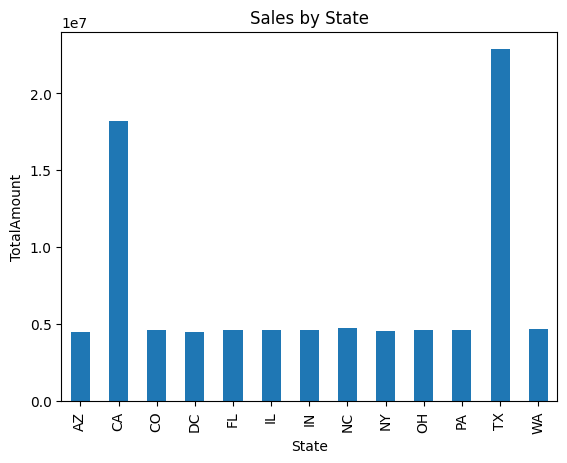

In [ ]:
# Visualization
# bar chart of Sales by State
df.groupby("State")["TotalAmount"].sum().plot(kind='bar')
plt.title("Sales by State")
plt.xlabel('State')
plt.ylabel('TotalAmount')
plt.show()

<Axes: xlabel='State'>

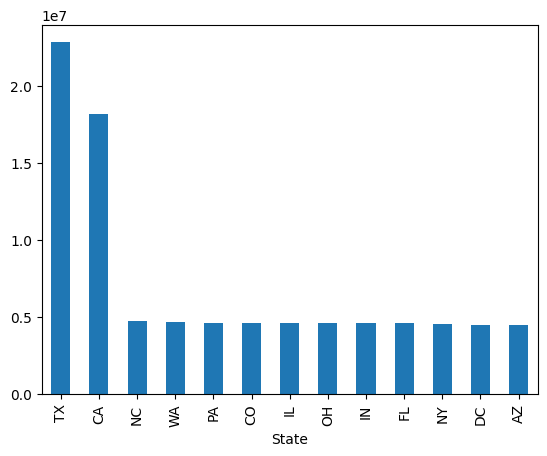

In [ ]:
df.groupby("State")["TotalAmount"].sum().sort_values(ascending=False).plot(kind='bar')

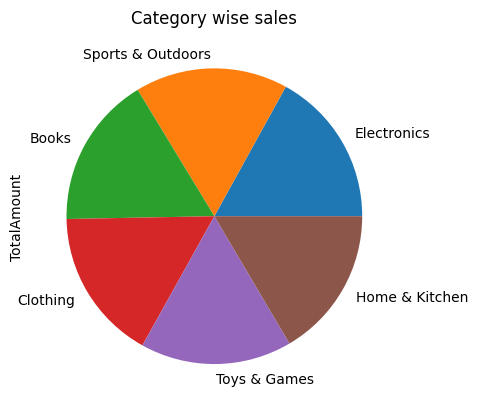

In [ ]:
# Category by sales
df.groupby("Category")["TotalAmount"].sum().sort_values(ascending=False).plot(kind='pie')
plt.title("Category wise sales")
plt.show()

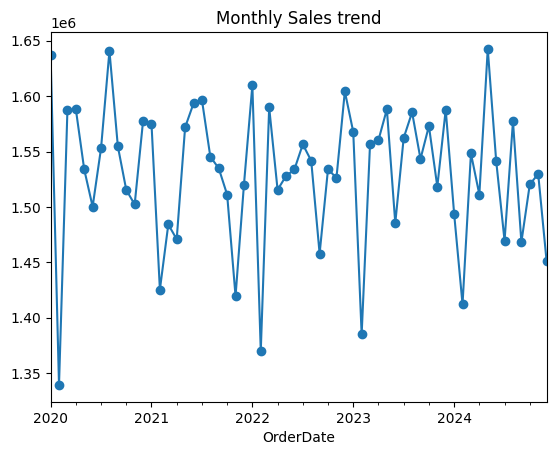

In [ ]:
df.groupby(df["OrderDate"].dt.to_period("M"))["TotalAmount"].sum().plot(kind='line',marker='o')
plt.title("Monthly Sales trend")
plt.show()

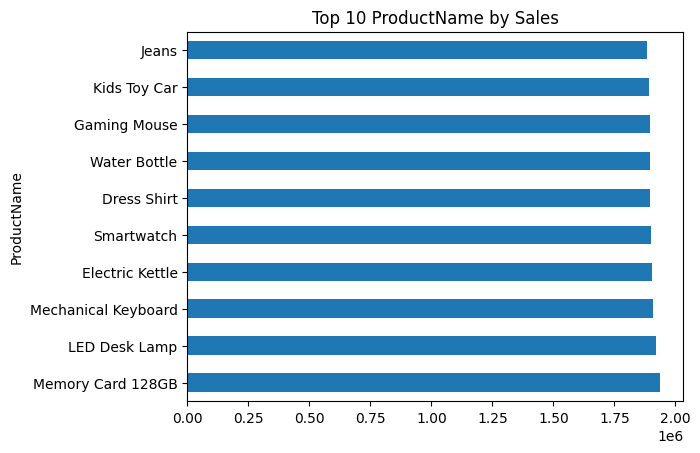

In [ ]:
# Top 10 products by Sales
df.groupby("ProductName")["TotalAmount"].sum().sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top 10 ProductName by Sales")
plt.show()

In [ ]:
df.groupby("State")["TotalAmount"].sum().sort_values(ascending=True)

,TotalAmount
State,
AZ,4504324.19
DC,4520876.11
NY,4554358.08
FL,4597177.27
IN,4609048.43
OH,4615442.32
IL,4632847.44
CO,4638498.97
PA,4650673.88


In [ ]:
# business questions
1. Total Sales = np.float64(91825647.92)
   Average order value = np.float64(918.2564792000001)
2. Highest sales = TX
   Lowest sales = AZ
3. Highest Revenue = Electronics
4. Top 10 products based on Sales
     Jeans, Kids Toy Car, Gaming Mouse, Water Bottle, Dress Shirt, Smart Watch, Electric Kettle, Mechanical Keyboard, LED Desk Lamp, Memory Card 128GB.
5. Top 5 customers
    Pooja Kapoor
    Vihaan Singh
    Pooja Singh
    Kabir Joshi
    Aditya Gupta
6. PaymentMethod most preferred by customers is Credit Card
7. Month which has highest sales is Highest Sales Month: 2024-05
Sales: 1642609.94
8. Categories or products with high sales is Electronics
9. State or city that requires improvement in sales is: State= AZ
  possible business strategies includes offering discounts, improving product availability,promotional campaigns etc
10. Focus on low performing cities or states.
    Promote high selling categories or products.
    Improve customer retention strategy.
